In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub
import os 

/opt/miniconda3/envs/seinfeld_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("thec03u5/seinfeld-chronicles")
print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: /Users/darialeykin/.cache/kagglehub/datasets/thec03u5/seinfeld-chronicles/versions/1
['episode_info.csv', 'scripts.csv']


In [3]:
episodes = pd.read_csv(os.path.join(path, 'episode_info.csv'))
scripts = pd.read_csv(os.path.join(path, 'scripts.csv'))

### EDA

In [4]:
episodes.head()

,Unnamed: 0,Season,EpisodeNo,Title,AirDate,Writers,Director,SEID
0,0,1.0,1.0,"Good News, Bad News","July 5, 1989","Larry David, Jerry Seinfeld",Art Wolff,S01E01
1,1,1.0,1.0,The Stakeout,"May 31, 1990","Larry David, Jerry Seinfeld",Tom Cherones,S01E01
2,2,1.0,2.0,The Robbery,"June 7, 1990",Matt Goldman,Tom Cherones,S01E02
3,3,1.0,3.0,Male Unbonding,"June 14, 1990","Larry David, Jerry Seinfeld",Tom Cherones,S01E03
4,4,1.0,4.0,The Stock Tip,"June 21, 1990","Larry David, Jerry Seinfeld",Tom Cherones,S01E04


In [5]:
scripts.head()

,Unnamed: 0,Character,Dialogue,EpisodeNo,SEID,Season
0,0,JERRY,Do you know what this is all about? Do you kno...,1.0,S01E01,1.0
1,1,JERRY,"(pointing at Georges shirt) See, to me, that b...",1.0,S01E01,1.0
2,2,GEORGE,Are you through?,1.0,S01E01,1.0
3,3,JERRY,"You do of course try on, when you buy?",1.0,S01E01,1.0
4,4,GEORGE,"Yes, it was purple, I liked it, I dont actuall...",1.0,S01E01,1.0


In [6]:
scripts.info()

<class 'pandas.DataFrame'>
RangeIndex: 54616 entries, 0 to 54615
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  54616 non-null  int64  
 1   Character   54616 non-null  str    
 2   Dialogue    54605 non-null  str    
 3   EpisodeNo   54616 non-null  float64
 4   SEID        54616 non-null  str    
 5   Season      54616 non-null  float64
dtypes: float64(2), int64(1), str(3)
memory usage: 2.5 MB


In [7]:
scripts.describe()

,Unnamed: 0,EpisodeNo,Season
count,54616.000000,54616.000000,54616.000000
mean,27307.500000,11.360737,5.677732
std,15766.425488,6.757064,2.243955
min,0.000000,1.000000,1.000000
25%,13653.750000,5.000000,4.000000
50%,27307.500000,11.000000,6.000000
75%,40961.250000,17.000000,8.000000
max,54615.000000,24.000000,9.000000


In [8]:
scripts.Character = scripts.Character.astype(str)
scripts.Dialogue = scripts.Dialogue.astype(str)
scripts = scripts[["Character","Dialogue"]]

In [9]:
scripts

,Character,Dialogue
0,JERRY,Do you know what this is all about? Do you kno...
1,JERRY,"(pointing at Georges shirt) See, to me, that b..."
2,GEORGE,Are you through?
3,JERRY,"You do of course try on, when you buy?"
4,GEORGE,"Yes, it was purple, I liked it, I dont actuall..."
...,...,...
54611,JERRY,Grand theft auto - don't steal any of my jokes.
54612,PRISONER 3,You suck - I'm gonna cut you.
54613,JERRY,"Hey, I don't come down to where you work, and ..."
54614,GUARD,"Alright, Seinfeld, that's it. Let's go. Come on."


#### drop the '[setting' for character based eda

In [10]:
to_drop1 = scripts[~scripts['Character'].astype(str).str.strip().str.startswith('[')]
to_drop2 = scripts[scripts['Dialogue'].isna()].index.tolist()
# scripts = scripts.drop(to_drop1)
scripts = scripts.drop(to_drop2)

## Character - Based EDA

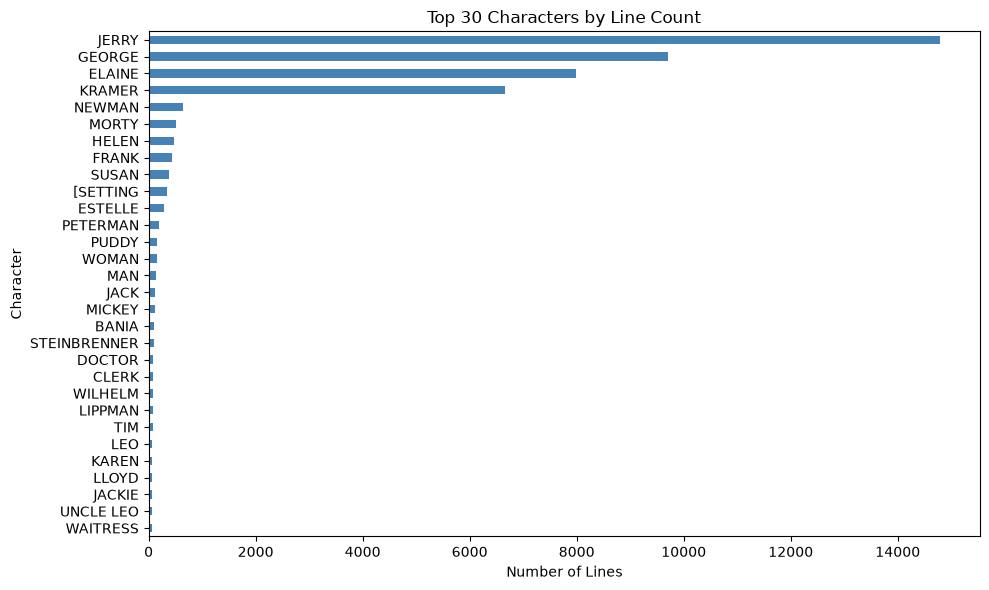

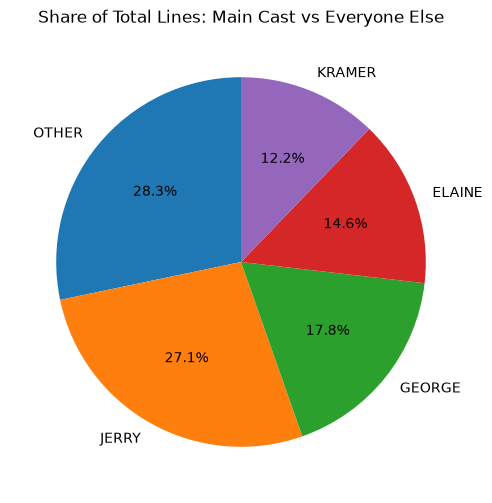

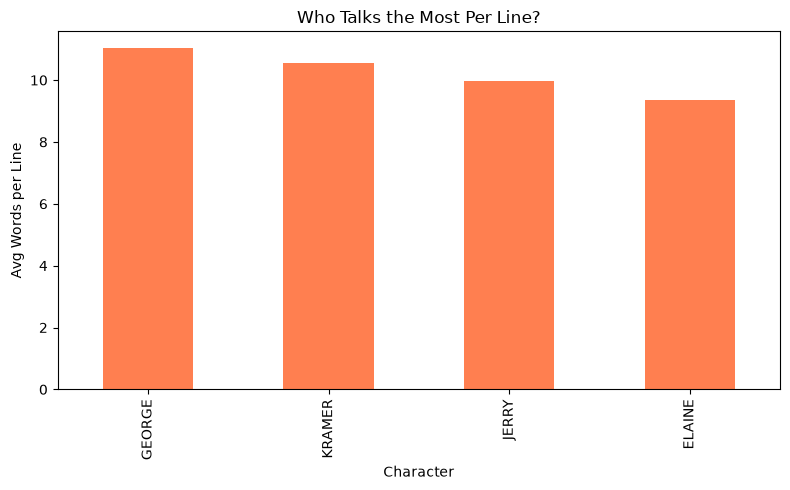

In [11]:
# which character said the most lines?
main_chars = ['JERRY', 'GEORGE', 'ELAINE', 'KRAMER']

def line_counts_plot(df,top):
    df = df.copy()
    plt.figure(figsize=(10, 6))
    line_counts = df['Character'].str.strip().str.upper().value_counts().head(top)
    line_counts.plot(kind='barh', color='steelblue')
    plt.xlabel('Number of Lines')
    plt.title(f'Top {top} Characters by Line Count')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def main_vs_else(df, main_chars):
    df = df.copy()
    df['Character'] = df['Character'].str.strip().str.upper()
    df['Group'] = df['Character'].apply(lambda x: x if x in main_chars else 'OTHER')
    group_counts = df['Group'].value_counts()
    plt.figure(figsize=(10, 6))
    plt.pie(group_counts, labels=group_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title('Share of Total Lines: Main Cast vs Everyone Else')
    plt.show()

def who_rambles_most(df, main_chars):
    df = df.copy()
    df['word_count'] = df['Dialogue'].astype(str).str.split().str.len()
    avg_words = (df[df['Character'].isin(main_chars)]
                    .groupby('Character')['word_count']
                    .mean()
                    .sort_values(ascending=False))
    avg_words.plot(kind='bar', color='coral', figsize=(8,5))
    plt.ylabel('Avg Words per Line')
    plt.title('Who Talks the Most Per Line?')
    plt.tight_layout()
    plt.show()

line_counts_plot(scripts,30)
main_vs_else(scripts,main_chars)
who_rambles_most(scripts,main_chars)




#### Semantic search

In [ ]:
# # %pip install sentence-transformers faiss-cpu
# from sentence_transformers import SentenceTransformer
# from sentence_transformers import util

In [ ]:
# Load a pre-trained model (https://www.sbert.net/)
model = SentenceTransformer('all-MiniLM-L6-v2') 

# flatten the dialogue in the df to list, make sure to clean it before for better results
corpus = scripts['Dialogue'].tolist() 

# create embeddings to the scripts
corpus_embeddings = model.encode(corpus, convert_to_tensor = True, show_progress_bar = True)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6634.52it/s]


In [33]:
def semantic_search(query, top_k=20):
    # create embedding to the query
    query_embedding = model.encode(query, convert_to_tensor=True)

    hits = util.semantic_search(query_embedding, corpus_embeddings, top_k=top_k)[0]
    
    results = scripts.iloc[[hit['corpus_id'] for hit in hits]].copy()
    results['score'] = [hit['score'] for hit in hits]
    return results[['Character', 'Dialogue', 'score']]

In [28]:
# save embedding cache
np.save('seinfeld_embeddings.npy', corpus_embeddings.cpu().numpy())
# reload later with: corpus_embeddings = torch.tensor(np.load('seinfeld_embeddings.npy'))

In [ ]:
semantic_happy = semantic_search("happy")
# semantic_sad = semantic_search("sad")
# semantic_angry = semantic_search("angry")
# semantic_excited = semantic_search("excited")
# semantic_love = semantic_search("love")

def plot_semantics(df, query):
    df = df.copy()
    line_counts = (df.groupby('Character')
                    .size()
                    .sort_values(ascending=False))
    line_counts.plot(kind='bar', color='coral', figsize=(8,5))
    plt.ylabel('Lines per Character')
    plt.title(query)
    plt.tight_layout()
    plt.show()
    

In [ ]:
# mask to a character


kramer_mask = scripts['Character'].str.upper() == 'KRAMER'
kramer_results = semantic_search("hungry", top_k=50)
kramer_results = kramer_results[kramer_results['Character'].str.upper() == 'KRAMER']
print(kramer_results)

      Character                     Dialogue     score
11748    KRAMER    Getting something to eat.  0.669909
22104    KRAMER  hey, you're hungry? Monk's?  0.561544


In [ ]:
main_chars = ['JERRY', 'GEORGE', 'ELAINE', 'KRAMER']

search_results = semantic_search("I'm hungry", top_k=50)

filtered_results = search_results[search_results['Character'].str.upper().isin(main_chars)]

print(filtered_results)



      Character                                           Dialogue     score
17730    ELAINE                               I'm *really* hungry!  0.764897
11619    GEORGE                                    I'm starving...  0.752633
3977      JERRY                        Boy, you are really hungry.  0.703530
3943     ELAINE          Let's go someplace else, I am too hungry.  0.698022
41176     JERRY              No.. No thanks, I'm, just not hungry.  0.693715
53595    ELAINE                         I thought you were hungry.  0.684871
15028    ELAINE                             You're eating my food!  0.674977
53587    GEORGE                                 Man, I'm starving.  0.671754
1019     ELAINE                        I dont care, Im not hungry.  0.658753
32207     JERRY          "I'm hungry. Let's get something to eat."  0.634805
12368     JERRY                    All of a sudden you get hungry?  0.631397
45267    ELAINE       No, actually I'm... I'm just kind of hungry.  0.623090

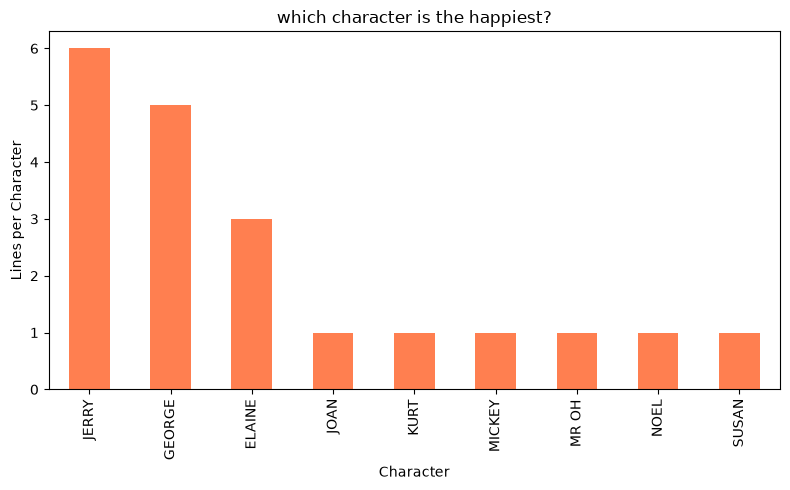

In [45]:
plot_semantics(semantic_happy, "which character is the happiest?")

In [49]:
semantic_happy[semantic_happy['Character'] == 'GEORGE']

,Character,Dialogue,score
44167,GEORGE,(pointing out the positive) But happy.,0.545295
34477,GEORGE,Happy? Why should I be happy?,0.533043
41696,GEORGE,Smile,0.532330
41725,GEORGE,Smile.,0.530068
28949,GEORGE,You,0.474346


In [50]:
semantic_happy[semantic_happy['Character'] == 'JERRY']

,Character,Dialogue,score
34476,JERRY,"Yeah. Wha - wha - what are you, happy?",0.504635
18656,JERRY,Satisfied?,0.496457
4657,JERRY,I'm not happy.,0.494160
22378,JERRY,thanks,0.494043
44243,JERRY,"Well, you seem happy.",0.488140
34478,JERRY,"I don't know, but you look like you're happy.",0.478438
